In [13]:
import pandas as pd
import numpy as np
import chardet
import traceback
import matplotlib
# Use a non-interactive backend for Matplotlib (no GUI)
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from wordcloud import WordCloud 
import datetime
import time
from datetime import timedelta
from cachetools import cached, TTLCache
from typing import Tuple
import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import stopwordsiso as swiso  # For more comprehensive stopwords
import plotly.graph_objects as go
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse
import os
import io
import base64
import json
import plotly.io as pio
# Initialize stopwords and sentiment analyzer
stop_words = set(stopwords.words('english'))
analyzer = SentimentIntensityAnalyzer()
# Merge multiple stopword lists
nltk_stopwords = set(stopwords.words('english'))
sklearn_stopwords = ENGLISH_STOP_WORDS
iso_stopwords = swiso.stopwords('en')  # English stopwords from stopwordsiso

# Combine all stopwords into a single set
combined_stopwords = nltk_stopwords | sklearn_stopwords | iso_stopwords

Filtered DataFrame shape: (1, 2)
Length of concatenated news text: 733
Computed sentiment gauge value (VADER): 34


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\VivekPol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


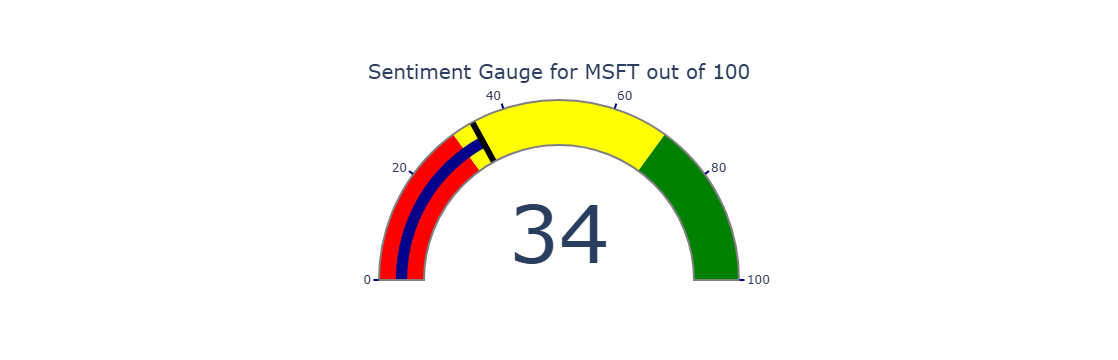

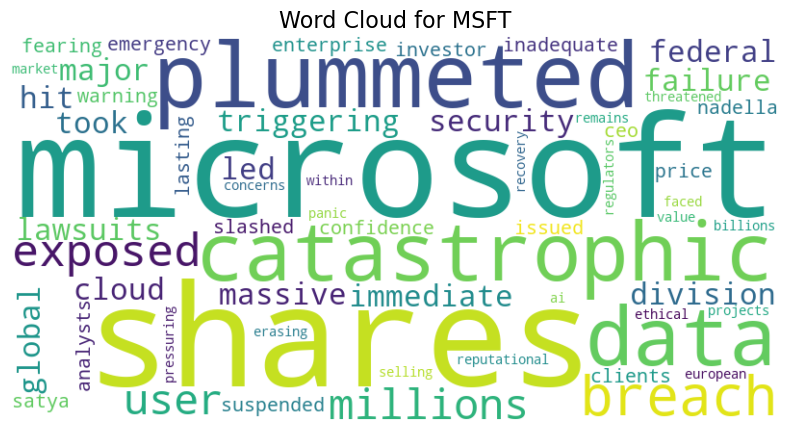

In [3]:


# Setup stopwords and initialize the VADER sentiment analyzer
stop_words = set(stopwords.words('english'))
analyzer = SentimentIntensityAnalyzer()

# Load the dataset from your CSV path using cp1252 encoding
csv_path = r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\testPairsTrading_news.csv"
df = pd.read_csv(csv_path, encoding="cp1252", skipinitialspace=True)
# Keep only the necessary columns; adjust column names if needed
df = df[['TICKER', 'NEWS']]

# Choose a ticker to analyze (e.g. "AAPL")
ticker = "MSFT"
df_filtered = df[df["TICKER"].str.upper() == ticker.upper()]
print("Filtered DataFrame shape:", df_filtered.shape)

# Concatenate all news entries into a single text block
news_text = " ".join(df_filtered["NEWS"].astype(str).tolist())
print("Length of concatenated news text:", len(news_text))

# --- Sentiment Analysis using VADER ---
# Split the news text into items (using period as delimiter)
news_items = news_text.split(".")
compound_scores = []
for item in news_items:
    item = item.strip()
    if item:
        vs = analyzer.polarity_scores(item)
        compound_scores.append(vs["compound"])

if compound_scores:
    avg_compound = sum(compound_scores) / len(compound_scores)
    # Map average compound score (-1 to 1) to a 0-100 scale
    gauge_value = int(((avg_compound + 1) / 2) * 100)
    print("Computed sentiment gauge value (VADER):", gauge_value)
else:
    gauge_value = 50
    print("No sentiment analysis results; defaulting gauge value to 50.")

# --- Plotly Gauge Indicator (Car Speedometer Style) ---
fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = gauge_value,
    title = {'text': f"Sentiment Gauge for {ticker} out of 100"},
    gauge = {
        'shape': "angular",
        'axis': {'range': [None, 100], 'tickwidth': 2, 'tickcolor': "darkblue"},
        'bar': {'color': "darkblue", 'thickness': 0.25},
        'bgcolor': "white",
        'borderwidth': 2,
        'bordercolor': "gray",
        'steps': [
            {'range': [0, 30], 'color': "red"},
            {'range': [30, 70], 'color': "yellow"},
            {'range': [70, 100], 'color': "green"}
        ],
        'threshold': {
            'line': {'color': "black", 'width': 6},
            'thickness': 1,
            'value': gauge_value
        }
    }
))
fig.show()

# --- Word Cloud Generation ---
# Clean the text for the word cloud: convert to lowercase, split into words,
# and remove non-alphabetic tokens, stopwords, and the ticker.
banned_words = {ticker.lower()}  # Exclude the ticker (e.g., "aapl")
words = news_text.lower().split()
words = [word for word in words if word.isalpha() and word not in stop_words and word not in banned_words]
cleaned_text = " ".join(words)

if cleaned_text.strip():
    # Create a decorative word cloud
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",     # White background for a clean look
        colormap="viridis",           # Vibrant colormap; you can try others like 'plasma' or 'inferno'
        max_words=200,
        contour_width=3,              # Adds a contour (border) around the words
        contour_color="steelblue"     # Color for the contour
        # Optionally, add a custom font path:
        # font_path="path/to/your/decorative_font.ttf",
        # Optionally, use a mask for a shaped word cloud:
        # mask=your_mask_array,
    ).generate(cleaned_text)
    
    # Display the word cloud using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {ticker}", fontsize=16)
    plt.show()
else:
    print("No valid content for generating a word cloud.")


In [249]:
df['TICKER'].unique()

array(['AAPL', 'AMD', 'EBAY', 'HPQ', 'IBM', 'JNPR', 'MSFT', 'QCOM'],
      dtype=object)

In [27]:
csv_path = r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\testPairsTrading_news.csv"

In [29]:
def detect_encoding(file_path):
    with open(file_path, 'rb') as f:
        result = chardet.detect(f.read())
    return result['encoding']

In [43]:
def news_sentiment(csv_path, ticker):
    """
    Extract the news headline and hyperlink for a specific ticker from the dataset.
    
    Parameters:
    csv_path (str): Path to the CSV file containing news data.
    ticker (str): Ticker symbol to filter news for.
    
    Returns:
    dict: Dictionary containing the news headline and link, or an empty dictionary if not found.
    """
    try:
        # Read the CSV file
        encoding = detect_encoding(csv_path)
        df = pd.read_csv(csv_path, encoding=encoding)        
        # Ensure the dataset contains the required columns
        if 'TICKER' not in df.columns or 'NEWS' not in df.columns or 'LINK' not in df.columns:
            print("Missing required columns in CSV file.")
            return {}

        # Filter by ticker (case-insensitive)
        ticker = ticker.upper()
        ticker_row = df[df['TICKER'].str.upper() == ticker].head(1)  # Fetch only the first match

        if ticker_row.empty:
            print(f"No news found for ticker: {ticker}")
            return {}

        # Extract the first news item
        news_item = {
            'headline': ticker_row['NEWS'].values[0],
            'link': ticker_row['LINK'].values[0]
        }

        return news_item['headline']

    except Exception as e:
        print(f"Error processing CSV file: {e}")
        return {}


In [45]:
news_sentiment(csv_path, 'JNPR')

'Juniper Networks stock plunged 30% after multiple enterprise clients canceled contracts, citing poor product performance. A leaked report revealed major cybersecurity vulnerabilities in Juniper’s networking hardware, shaking customer confidence. Revenue guidance was slashed, as analysts warned of prolonged market share losses. Several key executives resigned abruptly, raising concerns about internal turmoil. Juniper’s inability to compete with Cisco and Arista Networks further fueled investor panic. Lawsuits from affected clients added to the crisis, while regulatory scrutiny mounted. The stock hit a five-year low as analysts downgraded Juniper to “strong sell,” forecasting prolonged instability and uncertain recovery prospects.'

In [47]:
!pip install stopwordsiso

Defaulting to user installation because normal site-packages is not writeable


In [27]:

df = pd.read_csv(r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\testPairsTrading_prices.csv")

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6489 entries, 0 to 6488
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6489 non-null   object 
 1   AAPL    6489 non-null   float64
 2   AMD     6489 non-null   float64
 3   EBAY    6489 non-null   float64
 4   HPQ     6489 non-null   float64
 5   IBM     6489 non-null   float64
 6   JNPR    6489 non-null   float64
 7   MSFT    6489 non-null   float64
 8   QCOM    6489 non-null   float64
dtypes: float64(8), object(1)
memory usage: 456.4+ KB


In [31]:
df['Date'].head()

0    2000-01-03
1    2000-01-04
2    2000-01-05
3    2000-01-06
4    2000-01-07
Name: Date, dtype: object

In [19]:

df = pd.read_csv(r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo2\yahooData\testPairsTrading_prices.csv")

In [21]:
df

,Date,AAPL,AMD,EBAY,HPQ,IBM,JNPR,MSFT,QCOM
0,2000-01-03,0.843077,15.500000,6.714479,12.341937,58.897022,44.405514,35.864082,56.781086
1,2000-01-04,0.771996,14.625000,6.084626,11.409236,56.897854,42.453087,34.652569,51.318676
2,2000-01-05,0.783294,15.000000,6.491652,11.336982,58.897022,42.130371,35.017956,49.537472
3,2000-01-06,0.715509,16.000000,6.411437,10.614467,57.881561,40.274769,33.844925,44.352177
4,2000-01-07,0.749402,16.250000,6.405493,10.916611,57.627705,41.936745,34.287216,47.498978
...,...,...,...,...,...,...,...,...,...
6304,2025-01-27,229.860001,115.010002,66.839996,33.330002,224.130005,38.650002,434.559998,171.179993
6305,2025-01-28,238.259995,114.169998,67.190002,32.740002,225.660004,36.299999,447.200012,171.550003
6306,2025-01-29,239.360001,117.349998,66.000000,32.610001,228.630005,35.150002,442.329987,171.710007
6307,2025-01-30,237.589996,118.860001,67.519997,32.799999,258.269989,34.380001,414.989990,171.929993


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6309 entries, 0 to 6308
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6309 non-null   object 
 1   AAPL    6309 non-null   float64
 2   AMD     6309 non-null   float64
 3   EBAY    6309 non-null   float64
 4   HPQ     6309 non-null   float64
 5   IBM     6309 non-null   float64
 6   JNPR    6309 non-null   float64
 7   MSFT    6309 non-null   float64
 8   QCOM    6309 non-null   float64
dtypes: float64(8), object(1)
memory usage: 443.7+ KB


In [25]:
df['Date'].head()

0    2000-01-03
1    2000-01-04
2    2000-01-05
3    2000-01-06
4    2000-01-07
Name: Date, dtype: object

In [79]:
import pandas as pd

def fetch_news_headline(date, ticker):
    """
    Fetches all news headlines for a given date or month and stock ticker.

    Parameters:
    - date: string in "YYYY-MM-DD" or "YYYY-MM" format.
    - ticker: string representing the stock ticker.

    Returns:
    - A list of news headlines for the given date or month.
    """
    # Define the file paths for each ticker
    file_paths = {
        "AAPL": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\AAPL_news.csv",
        "AMD": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\AMD_news.csv",
        "EBAY": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\EBAY_news.csv",
        "HPQ": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\HPQ_news.csv",
        "IBM": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\IBM_news.csv",
        "JNPR": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\JNPR_news.csv",
        "MSFT": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\MSFT_news.csv",
        "QCOM": r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\QCOM_news.csv"
    }

    # Check if the ticker exists in the file paths
    if ticker not in file_paths:
        return []

    # Get the file path for the given ticker
    file_path = file_paths[ticker]

    try:
        # Load the dataset
        dataset = pd.read_csv(
            file_path,
            quotechar='"',
            skipinitialspace=True,
            usecols=['Date', 'NEWS'],
            encoding='ISO-8859-1'
        )

        # Convert the Date column to datetime format
        dataset['Date'] = pd.to_datetime(dataset['Date'], format='%Y-%m-%d')

        # Handle date filtering for single day or entire month
        if len(date) == 7:  # Format: YYYY-MM (for month)
            target_month = pd.to_datetime(date + "-01")
            filtered_data = dataset[
                (dataset['Date'].dt.year == target_month.year) &
                (dataset['Date'].dt.month == target_month.month)
            ]
        else:  # Format: YYYY-MM-DD (for a specific date)
            input_date = pd.to_datetime(date)
            filtered_data = dataset[dataset['Date'].dt.date == input_date.date()]

        # Extract all headlines for the given date/month
        headlines = filtered_data['NEWS'].dropna().tolist()

    except Exception as e:
        print(f"Error fetching news for {ticker} on {date}: {e}")
        headlines = []

    return headlines

In [95]:
# Example Usage:
# Extract news for a single date
date = "2024-01-24"   # Format: YYYY-MM-DD
ticker = "AAPL"
result = fetch_news_headline(date, ticker)
print(f"Headline for {ticker} on {date}: {result}")

Headline for AAPL on 2024-01-24: ['TSMC agrees to supply 2nm chips for iPhones launching in 2025.  ']


In [91]:
# Extract all news for a month
month = "2024-01"     # Format: YYYY-MM
result = fetch_news_headline(month, ticker)
print(f"All headlines for {ticker} in {month}:")
for i, headline in enumerate(result, start=1):
    print(f"{i}. {headline}")

All headlines for AAPL in 2024-01:
1. The Apple Pencil 3 is rumored to include haptic feedback and magnetic charging.  
2. Apple refreshes the Mac Studio with the M3 Ultra chip, targeting professional creatives.  
3. The U.S. Department of Justice files an antitrust lawsuit against Apple, targeting its App Store practices.  
4. The European Union fines Apple $1.3 billion for anti-competitive behavior in the music streaming market.  
5. Epic Games wins an appeal, forcing Apple to allow third-party payment systems.  
6. A class-action lawsuit alleges Apple overprices iCloud storage.  
7. Apple complies with the EU Digital Markets Act, enabling iOS sideloading in 2024.  
8. A patent dispute with Masimo temporarily halts Apple Watch sales in the U.S.  
9. China bans government workers from using Apple devices over security concerns.  
10. India imposes a 22% tariff on iPhones, pushing Apple to expand local manufacturing.  
11. Apple settles a $500 million lawsuit over iPhone performance th

In [3]:
def get_recent_news(csv_path, start_date, end_date):
    """Fetches recent news within the specified date range from the CSV file. It is for Company news section"""
    try:
        encoding = detect_encoding(csv_path)
        df = pd.read_csv(csv_path, encoding=encoding)
        
        if df.empty:
            return []

        df.replace(np.nan, '', inplace=True)

        if 'Date' not in df.columns or 'NEWS' not in df.columns or 'LINK' not in df.columns:
            print("Missing required columns in CSV file.")
            return []

        # Convert date column to datetime
        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
        df = df.dropna(subset=['Date'])

        # Convert input dates to datetime
        start_date = pd.to_datetime(start_date, errors='coerce')
        end_date = pd.to_datetime(end_date, errors='coerce')

        if pd.isna(start_date) or pd.isna(end_date):
            print("Invalid date format provided.")
            return []

        # Filter data based on the provided date range
        mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
        df_filtered = df.loc[mask]

        if df_filtered.empty:
            print(f"No news data available between {start_date.date()} and {end_date.date()}.")
            return []

        df_filtered = df_filtered.sort_values(by='Date', ascending=False)
        recent_news = df_filtered[['Date', 'NEWS', 'LINK']].to_dict(orient='records')

        return recent_news

    except Exception as e:
        print(f"Error processing CSV file: {e}")
        return []

In [9]:
def detect_encoding(file_path):
    with open(file_path, 'rb') as f:
        result = chardet.detect(f.read())
    return result['encoding']

In [11]:
start_date = "2024-01-24"   # Format: YYYY-MM-DD
end_date = "2024-02-24"
ticker = "AAPL"
csv_path = r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\AMD_news.csv",


In [13]:
get_recent_news(csv_path, start_date, end_date)

Error processing CSV file: expected str, bytes or os.PathLike object, not tuple


[]

In [3]:
import requests
from bs4 import BeautifulSoup

def extract_news(url: str, symbol: str) -> dict:
    """
    Extracts news text from the given URL.

    Args:
        url (str): The URL of the news page.
        symbol (str): The stock symbol.

    Returns:
        dict: A dictionary containing the symbol, title, and news text.
    """
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()

        soup = BeautifulSoup(response.content, "html.parser")

        # Extract title
        title = soup.find("h1").get_text(strip=True) if soup.find("h1") else "No title found"

        # Extract news content
        paragraphs = soup.find_all("p")
        news_text = " ".join(p.get_text(strip=True) for p in paragraphs)

        return {
            "symbol": symbol,
            "title": title,
            "news_text": news_text
        }

    except Exception as e:
        return {
            "symbol": symbol,
            "error": str(e)
        }



In [7]:
# Example usage
url = "https://stockanalysis.com/ipos/news/"
symbol = "LGPS"
news_data = extract_news(url, symbol)
print(news_data)

{'symbol': 'LGPS', 'title': 'IPO News', 'news_text': 'Two small issuers listed in the US, joined by two SPACs. The biggest news on the calendar came from CoreWeave, which launched its $2.5 billion IPO. Three IPOs are scheduled to list ahead, although som... Bluemount Holdings Limited\'s IPO is highly risky due to declining revenue, unrealistic valuation expectations, and significant customer concentration. The company\'s administrative costs are rising whi... KKR & Co. Inc. has issued a 6.25% Series D Mandatory Convertible Preferred Stock, trading at $49.36 with a Yield to Maturity of 6.98%. The new preferred stock is not rated by S&P, Moody\'s, or Fitch, a... CoreWeave, a cloud-computing provider backed by Nvidia (NVDA), announced it is going public. The company seeks to raise $2.7 billion for its initial public offering (IPO). CoreWeave said in its updated IPO prospectus that it plans to sell shares at $47 to $55 each, raising a total of up to $2.7 billion. The company is attempting 

In [17]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse

def extract_news(url: str, symbol: str) -> dict:
    """
    Searches for the symbol by constructing the correct URL and extracts news.

    Args:
        url (str): The base URL (e.g., "https://stockanalysis.com/ipos/news/").
        symbol (str): The stock symbol to search for (e.g., "AMD").

    Returns:
        dict: A dictionary containing the symbol, page title, news text, and the source URL,
              or an error message if something went wrong.
    """
    try:
        # Extract the scheme and netloc (domain) from the provided URL.
        parsed_url = urlparse(url)
        base = f"{parsed_url.scheme}://{parsed_url.netloc}"
        
        # Construct the proper search URL using the domain.
        search_url = f"{base}/stocks/{symbol}/"
        
        response = requests.get(search_url, timeout=10)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, "html.parser")

        # Extract the page title (if available)
        title_tag = soup.find("h1")
        title = title_tag.get_text(strip=True) if title_tag else "No title found"
        
        # Attempt to locate a container with news; if not found, fallback to all <p> tags.
        news_container = soup.find("div", class_="news-content")
        if news_container:
            paragraphs = news_container.find_all("p")
        else:
            paragraphs = soup.find_all("p")
        
        news_text = " ".join(p.get_text(strip=True) for p in paragraphs)
        
        return {
            "symbol": symbol,
            "title": title,
            "news_text": news_text,
            "source_url": search_url
        }
    except Exception as e:
        return {
            "symbol": symbol,
            "error": str(e)
        }




In [21]:
# Example usage:
if __name__ == "__main__":
    base_url = "https://stockanalysis.com/ipos/news/"
    symbol = "omse"
    news_data = extract_news(base_url, symbol)
    print(news_data)

{'symbol': 'omse', 'title': 'OMS Energy Technologies Inc. (OMSE)', 'news_text': 'OMS Energy Technologies a growth-oriented manufacturer of surface wellhead systems, or SWS, and oil country tubular goods, or OCTG products used in the oil and gas industry. These products are primarily used for both onshore and offshore oil exploration and production, or E&P activities in the Asia Pacific and the Middle Eastern and North Africa (MENA) Regions. Our products have been designed, manufactured and certified with the American Petroleum Standards (API) and International Organization of Standardization (ISO). Through our comprehensive...[Read more] OMS Energy Technologies Inc., a growth-oriented manufacturer of surface wellhead... OMS Energy Technologies, a Singapore-based manufacturer of surface wellhead systems and oil country tubular goods, filed on Monday with the SEC to raise up to $32 million in an initial public offering... OMS Energy Technologies has filed to go public with an IPO on the 

In [ ]:
def generate_sentiment_visuals(ticker: str, news_text: str) -> (str, str):
    """
    Generates a sentiment gauge (Plotly) and a word cloud (base64 PNG) from the provided news text.
    
    Args:
        ticker (str): The stock symbol.
        news_text (str): The news text to analyze.
    
    Returns:
        tuple: (gauge_html, wordcloud_base64)
    """
    # Initialize VADER sentiment analyzer
    analyzer = SentimentIntensityAnalyzer()

    # Split news_text into items (try newlines first, then by period if needed)
    news_items = [item for item in news_text.split('\n') if item.strip()]
    if not news_items:
        news_items = [item.strip() for item in news_text.split('.') if item.strip()]

    # Calculate compound sentiment scores for each news item
    compound_scores = [analyzer.polarity_scores(item)["compound"] for item in news_items if item.strip()]

    # Calculate average compound score and map it to a 0-100 gauge value
    if compound_scores:
        avg_compound = np.mean(compound_scores)
        gauge_value = int(((avg_compound + 1) / 2) * 100)
    else:
        gauge_value = 50  # Neutral fallback

    # Create a Plotly gauge chart
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=gauge_value,
        title={'text': f"Sentiment Gauge for {ticker.upper()} out of 100"},
        gauge={
            'shape': "angular",
            'axis': {'range': [None, 100]},
            'steps': [
                {'range': [0, 30], 'color': "red"},
                {'range': [30, 70], 'color': "yellow"},
                {'range': [70, 100], 'color': "green"}
            ],
            'threshold': {
                'line': {'color': "black", 'width': 4},
                'thickness': 0.75,
                'value': gauge_value
            }
        }
    ))
    # Convert Plotly figure to HTML string (to embed directly into the webpage)
    gauge_html = fig.to_html(full_html=False)

    # Prepare text for word cloud: remove stopwords and banned words
    combined_stopwords = set(stopwords.words('english'))
    banned_words = {ticker.lower(), "shares", "stocks", "company", "stock"}  # add more as needed

    words = [word for word in news_text.lower().split() 
             if word.isalpha() and word not in combined_stopwords and word not in banned_words]

    cleaned_text = " ".join(words)

    if cleaned_text.strip():
        # Generate the word cloud image
        wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(cleaned_text)
        # Save image to an in-memory bytes buffer
        img_buffer = io.BytesIO()
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.tight_layout(pad=0)
        plt.savefig(img_buffer, format="png")
        plt.close()  # free memory
        img_buffer.seek(0)
        # Encode image to base64 for direct embedding 
        wordcloud_base64 = base64.b64encode(img_buffer.getvalue()).decode("utf8")
    else:
        wordcloud_base64 = None

    return gauge_html, wordcloud_base64

In [17]:
def create_sentiment_gauge(ticker, gauge_value):
    """
    Create a sentiment gauge using Plotly.
    
    Args:
        ticker (str): The ticker symbol
        gauge_value (int): The gauge value (0-100)
        
    Returns:
        str: HTML for the gauge
    """
    print(f"🔍 DEBUG: Starting gauge generation for {ticker} with value {gauge_value}")
    
    try:
        # Validate gauge value
        if gauge_value is None:
            gauge_value = 50  # Default to neutral
            
        # Ensure gauge value is within range
        gauge_value = max(0, min(100, gauge_value))
        
        # Create a unique ID for this gauge
        gauge_id = f"gauge-{ticker.lower()}-{int(time.time())}"
        print(f"🔍 DEBUG: Created unique gauge ID: {gauge_id}")
        
        # Create the gauge figure
        fig = go.Figure(go.Indicator(
            mode="gauge+number",
            value=gauge_value,
            title={'text': f"Sentiment Gauge for {ticker.upper()} out of 100"},
            gauge={
                'shape': "angular",
                'axis': {'range': [None, 100]},
                'steps': [
                    {'range': [0, 30], 'color': "red"},
                    {'range': [30, 70], 'color': "yellow"},
                    {'range': [70, 100], 'color': "green"}
                ],
                'threshold': {
                    'line': {'color': "black", 'width': 4},
                    'thickness': 0.75,
                    'value': gauge_value
                }
            },
            domain={'x': [0, 1], 'y': [0, 1]}
        ))
        
        # Set figure layout
        fig.update_layout(
            autosize=True,
            height=300,
            margin=dict(l=20, r=20, t=30, b=20),
            paper_bgcolor="white",
            font=dict(size=12)
        )
        
        # Instead of using Plotly's to_html method, create a direct implementation
        # that doesn't rely on the CDN version of Plotly
        wrapped_html = f'''
        <div id="{gauge_id}-container" class="gauge-container" style="min-height:300px; height:300px; width:100%; position:relative; border:3px solid #ff0000;">
            <!-- Simple fallback visualization -->
            <div style="text-align:center; padding:20px;">
                <h3>Sentiment Score: {gauge_value}/100</h3>
                <div style="width:80%; height:30px; background:#eee; margin:20px auto; border-radius:15px;">
                    <div style="width:{gauge_value}%; height:100%; background-color:{
                        '#ff6666' if gauge_value < 30 else 
                        '#ffff66' if gauge_value <= 70 else 
                        '#66ff66'
                    };"></div>
                </div>
                <div style="font-size:20px; font-weight:bold; margin-top:10px;">
                    {gauge_value}/100 - {
                        'Negative' if gauge_value < 30 else
                        'Neutral' if gauge_value <= 70 else
                        'Positive'
                    }
                </div>
            </div>
            
            <!-- Plotly will render here if available -->
            <div id="{gauge_id}" style="width:100%; height:300px;"></div>
            
            <!-- Inline script to create the Plotly gauge -->
            <script>
                // Create a function that will be called when the page loads
                function createGauge_{gauge_id.replace('-', '_')}() {{
                    console.log("Creating gauge with ID: {gauge_id}");
                    
                    // Check if Plotly is available
                    if (typeof Plotly === 'undefined') {{
                        console.error("Plotly is not available for gauge {gauge_id}");
                        document.getElementById('{gauge_id}-container').innerHTML += 
                            '<div style="color:red; text-align:center;">Plotly library not loaded</div>';
                        return;
                    }}
                    
                    try {{
                        // Create the data for Plotly
                        var data = [{{
                            type: "indicator",
                            mode: "gauge+number",
                            value: {gauge_value},
                            title: {{ text: "Sentiment Gauge for {ticker.upper()} out of 100" }},
                            gauge: {{
                                shape: "angular",
                                axis: {{ range: [null, 100] }},
                                steps: [
                                    {{ range: [0, 30], color: "red" }},
                                    {{ range: [30, 70], color: "yellow" }},
                                    {{ range: [70, 100], color: "green" }}
                                ],
                                threshold: {{
                                    line: {{ color: "black", width: 4 }},
                                    thickness: 0.75,
                                    value: {gauge_value}
                                }}
                            }},
                            domain: {{ x: [0, 1], y: [0, 1] }}
                        }}];
                        
                        // Create the layout
                        var layout = {{
                            autosize: true,
                            height: 300,
                            margin: {{ l: 20, r: 20, t: 30, b: 20 }},
                            paper_bgcolor: "white",
                            font: {{ size: 12 }}
                        }};
                        
                        // Render the plot
                        Plotly.newPlot('{gauge_id}', data, layout, {{
                            displayModeBar: false,
                            responsive: true
                        }});
                        
                        console.log("Gauge {gauge_id} created successfully");
                    }} catch (e) {{
                        console.error("Error creating gauge {gauge_id}:", e);
                        document.getElementById('{gauge_id}-container').innerHTML += 
                            '<div style="color:red; text-align:center;">Error creating gauge: ' + e.message + '</div>';
                    }}
                }}
                
                // Wait for DOM to be fully loaded
                if (document.readyState === 'loading') {{
                    document.addEventListener('DOMContentLoaded', createGauge_{gauge_id.replace('-', '_')});
                }} else {{
                    // DOM already loaded, create gauge immediately
                    createGauge_{gauge_id.replace('-', '_')}();
                }}
            </script>
        </div>
        '''
        
        print(f"✅ Successfully generated gauge HTML for {ticker}")
        return wrapped_html
        
    except Exception as e:
        print(f"❌ Error generating gauge: {str(e)}")
        import traceback
        traceback.print_exc()
        
        # Return a fallback visualization
        return f'''
        <div class="alert alert-warning">
            <p>Unable to generate gauge visualization for {ticker}.</p>
            <p style="color:red;">Error: {str(e)}</p>
        </div>
        '''

In [19]:
def analyze_sentiment(csv_path, ticker):
    """
    It is for Secntiment Analysis Section.
    Reads the CSV dataset, filters for the given ticker, computes the sentiment gauge value,
    generates a Plotly gauge chart and a Matplotlib word cloud, and returns both as in-memory objects.
    
    Returns:
        gauge_html (str): HTML representation of the Plotly gauge chart.
        wordcloud_base64 (str): Base64 string of the word cloud image, suitable for embedding.
    """
    try:
        
        # Load dataset and filter by ticker
        df = pd.read_csv(csv_path, encoding='cp1252', skipinitialspace=True)
        df = df[['TICKER', 'NEWS']]
        df_filtered = df[df['TICKER'].str.upper() == ticker.upper()]
        
        if df_filtered.empty:
            return None, None  # No data for this ticker
        
        # Concatenate news articles into one text
        news_text = " ".join(df_filtered["NEWS"].astype(str).tolist())
        
        # Split text into items and calculate compound scores using VADER
        news_items = news_text.split(".")
        compound_scores = [analyzer.polarity_scores(item.strip())["compound"] 
                        for item in news_items if item.strip()]
        
        # Calculate average compound score and map it to a 0-100 gauge value
        if compound_scores:
            avg_compound = np.mean(compound_scores)
            gauge_value = int(((avg_compound + 1) / 2) * 100)
        else:
            gauge_value = 50  # Neutral fallback
        
        # Use the improved gauge creation function
        gauge_html = create_sentiment_gauge(ticker, gauge_value)
        
        # Word cloud generation with proper error handling
        wordcloud_base64 = None
        try:
        
            # Prepare text for word cloud: remove stopwords and the ticker itself
            banned_words = {ticker.lower(), "shares", "stocks", "company", "stock"}  # Banned words in lowercase
            # Clean the text
            words = [word for word in news_text.lower().split() if word.isalpha() 
                    and word not in combined_stopwords and word.lower() not in banned_words]

            cleaned_text = " ".join(words)
            
            if cleaned_text.strip():
                # Generate the word cloud image
                wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(cleaned_text)
                # Save image to an in-memory bytes buffer
                img_buffer = io.BytesIO()
                plt.figure(figsize=(10, 5))
                plt.imshow(wc, interpolation="bilinear")
                plt.axis("off")
                plt.tight_layout(pad=0)
                plt.savefig(img_buffer, format="png")
                plt.close()  # Close the figure to free memory
                img_buffer.seek(0)
                # Encode image to base64 for direct embedding 
                wordcloud_base64 = base64.b64encode(img_buffer.getvalue()).decode("utf8")
        except Exception as e:
            print(f"Error generating word cloud: {str(e)}")
            # Continue without word cloud

        return gauge_html, wordcloud_base64
    
    except Exception as e:
        print(f"Error in analyze_sentiment: {str(e)}")
        traceback.print_exc()
        # Return empty values that won't break the template
        return None, None

In [25]:
csv_path = r"C:\Users\VivekPol\OneDrive - ValueAdd Research and Analytics Solutions LLP\Desktop\Project\Vivek Project\Sentigrade_News_Analysis\Demo4\yahooData\testPairsTrading_news.csv"
ticker = 'AMD'

In [27]:
analyze_sentiment(csv_path, ticker)

🔍 DEBUG: Starting gauge generation for AMD with value 65
🔍 DEBUG: Created unique gauge ID: gauge-amd-1743592087
✅ Successfully generated gauge HTML for AMD


('\n        <div id="gauge-amd-1743592087-container" class="gauge-container" style="min-height:300px; height:300px; width:100%; position:relative; border:3px solid #ff0000;">\n            <!-- Simple fallback visualization -->\n            <div style="text-align:center; padding:20px;">\n                <h3>Sentiment Score: 65/100</h3>\n                <div style="width:80%; height:30px; background:#eee; margin:20px auto; border-radius:15px;">\n                    <div style="width:65%; height:100%; background-color:#ffff66;"></div>\n                </div>\n                <div style="font-size:20px; font-weight:bold; margin-top:10px;">\n                    65/100 - Neutral\n                </div>\n            </div>\n            \n            <!-- Plotly will render here if available -->\n            <div id="gauge-amd-1743592087" style="width:100%; height:300px;"></div>\n            \n            <!-- Inline script to create the Plotly gauge -->\n            <script>\n                